<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>APRENDIZADO DE MÁQUINA (CIC1205/GCC1932) - Trabalho 1</center></h1>

- Nome completo: Erich Johann
- [Link para vídeo](<LINK_VIDEO>)

# (1) Predição de pagamento de empréstimos

Iniciando abrindo dataset

In [24]:
import pandas as pd

df_dev = pd.read_csv("https://raw.githubusercontent.com/AILAB-CEFET-RJ/cic1205/main/data/credtrain.txt", sep="\t")
df_test = pd.read_csv("https://raw.githubusercontent.com/AILAB-CEFET-RJ/cic1205/main/data/credtest.txt", sep="\t")

column_names = ['ESCT', 'NDEP', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'ENTRADA', 'CLASSE']
df_dev.columns = column_names
df_test.columns = column_names

df_dev.head()

,ESCT,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,CLASSE
0,0,0,350,1,468,10,65,0,33,6,0,1
1,0,0,1100,0,829,9,125,0,56,48,0,1
2,0,0,3000,0,552,12,76,1,31,60,0,1
3,1,0,1000,0,809,12,111,0,24,7,0,1
4,0,0,300,0,331,6,74,1,41,0,0,1


Os dados aparentemente já estão codificados
Faremos uma análise incial do dataset a seguir

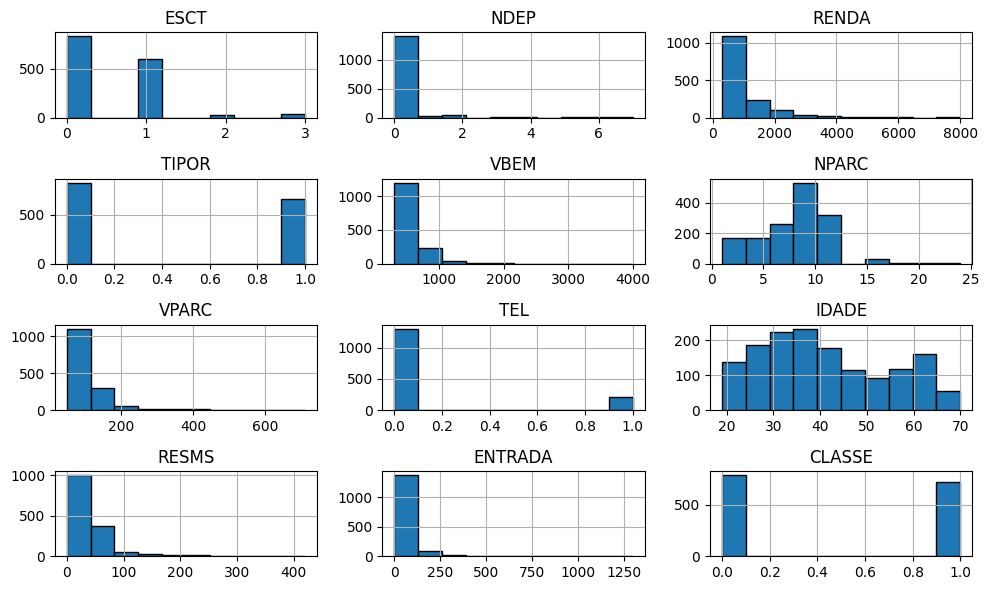

In [25]:
from matplotlib import pyplot as plt

df_dev.hist(figsize=(10, 6), edgecolor='black')
plt.tight_layout()
plt.show()

A classe alvo não está desbalanceada, o que é bom.
NPARC e IDADE apresentam uma distribuição que se assemelha a normal, se for o caso será aplicado normalização StandartScaler.
As variáveis RENDA, VBEM, VPARC, RESMS e ENTRADA apresentam assimetria a direita e tem valores altos que podem dominar outras variáveis, então aplicaremos normalização logaritima.

In [26]:
import scipy.stats as stats

def normal_test(data, label):
  stat, p_val = stats.shapiro(data)
  print(f'Estatística: {stat:.3f}, p-valor: {p_val:.3e}')

  if p_val > 0.1:
      print(f'A coluna {label} parece seguir uma distribuição normal.\n')
  else:
      print(f'A coluna {label} NÃO segue uma distribuição normal.\n')

normal_test(df_dev['NPARC'], 'NPARC')
normal_test(df_dev['IDADE'], 'IDADE')

Estatística: 0.917, p-valor: 6.868e-28
A coluna NPARC NÃO segue uma distribuição normal.

Estatística: 0.948, p-valor: 1.299e-22
A coluna IDADE NÃO segue uma distribuição normal.



Como nenhuma das distribuições é normal será usada normalização minmax

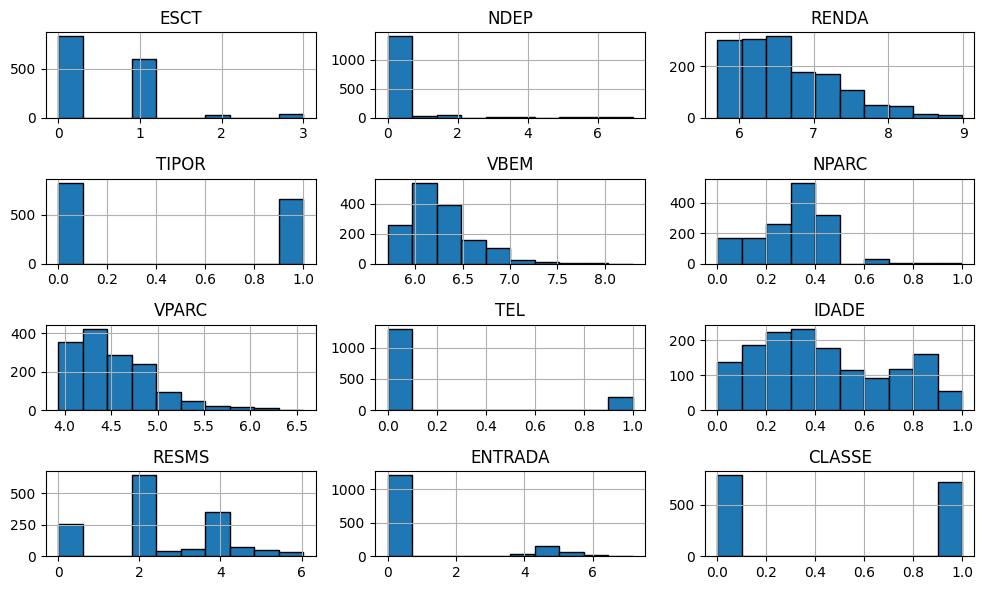

In [27]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

df_scaled = df_dev.copy()

Scaler_Idade = MinMaxScaler()
Scaler_Nparc = MinMaxScaler()

df_scaled['IDADE'] = Scaler_Idade.fit_transform(df_scaled[["IDADE"]])
df_scaled['NPARC'] = Scaler_Nparc.fit_transform(df_scaled[["NPARC"]])
df_scaled['RENDA'] = np.log1p(df_scaled['RENDA'])
df_scaled['VBEM'] = np.log1p(df_scaled['VBEM'])
df_scaled['VPARC'] = np.log1p(df_scaled['VPARC'])
df_scaled['RESMS'] = np.log1p(df_scaled['RESMS'])
df_scaled['ENTRADA'] = np.log1p(df_scaled['ENTRADA'])

df_scaled.hist(figsize=(10, 6), edgecolor='black')
plt.tight_layout()
plt.show()

# Normalização dados de teste APÓS separação

df_test["IDADE"] = Scaler_Idade.transform(df_test[["IDADE"]])
df_test["NPARC"] = Scaler_Nparc.transform(df_test[["NPARC"]])
df_test['RENDA'] = np.log1p(df_test['RENDA'])
df_test['VBEM'] = np.log1p(df_test['VBEM'])
df_test['VPARC'] = np.log1p(df_test['VPARC'])
df_test['RESMS'] = np.log1p(df_test['RESMS'])
df_test['ENTRADA'] = np.log1p(df_test['ENTRADA'])

Com os dados normalizados partiremos para o treinamento dos modelos

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

x_train = df_scaled.drop('CLASSE', axis=1)
y_train = df_scaled['CLASSE']
x_test = df_test.drop('CLASSE', axis=1)
y_test = df_test['CLASSE']

lr = LogisticRegression()
knn = KNeighborsClassifier()
gbc = GradientBoostingClassifier()

lr.fit(x_train, y_train)
knn.fit(x_train, y_train)
gbc.fit(x_train, y_train)

lr_pred = lr.predict(x_test)
knn_pred = knn.predict(x_test)
gbc_pred = gbc.predict(x_test)

print('\nLogistic Regression')
print(f'Acurácia: {accuracy_score(y_test, lr_pred)}')

print('\nKNN')
print(f'Acurácia: {accuracy_score(y_test, knn_pred)}')

print('\nGradient Boosting Classifier')
print(f'Acurácia: {accuracy_score(y_test, gbc_pred)}')


Logistic Regression
Acurácia: 0.8871527777777778

KNN
Acurácia: 0.8194444444444444

Gradient Boosting Classifier
Acurácia: 0.9010416666666666


Gerando curva ROC

[Logistic Regression] Limiar F1-Máximo: 0.5092 (F1-Score: 0.8787)

[KNN] Limiar F1-Máximo: 0.6000 (F1-Score: 0.7992)

[Gradient Boosting Classifier] Limiar F1-Máximo: 0.5284 (F1-Score: 0.8929)



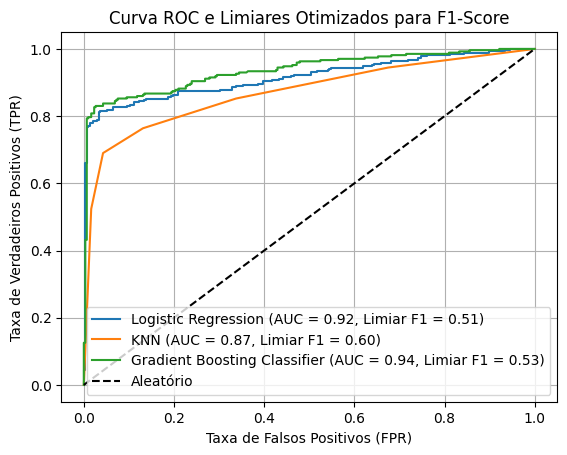

In [29]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def auc_curve(model, name):
  predition = model.predict_proba(x_test)[:, 1]

  fpr, tpr, _ = roc_curve(y_test, predition)
  roc_auc = auc(fpr, tpr)

  precision, recall, threshold = precision_recall_curve(y_test, predition)
  f1 = 2 * (precision * recall) / (precision + recall)

  best_idx = np.argmax(f1)
  best_thresh = threshold[best_idx]
  best_f1 = f1[best_idx]
  plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f}, Limiar F1 = {best_thresh:.2f})')

  print(f"[{name}] Limiar F1-Máximo: {best_thresh:.4f} (F1-Score: {best_f1:.4f})\n")


auc_curve(lr, 'Logistic Regression')
auc_curve(knn, 'KNN')
auc_curve(gbc, 'Gradient Boosting Classifier')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC e Limiares Otimizados para F1-Score')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

O código gera a curva ROC para os 3 modelos selecionando o limiar que maximaza o valor de F1. Já que ele combina as métricas de precisão e recall, procurando um meio termo entre distinguir o máximo de exemplos classe positiva e não gerar muitos falsos positivos.

A seguir é aplicado o melhor limiar e gerado um relatório no conjunto de teste que foi separado no início.

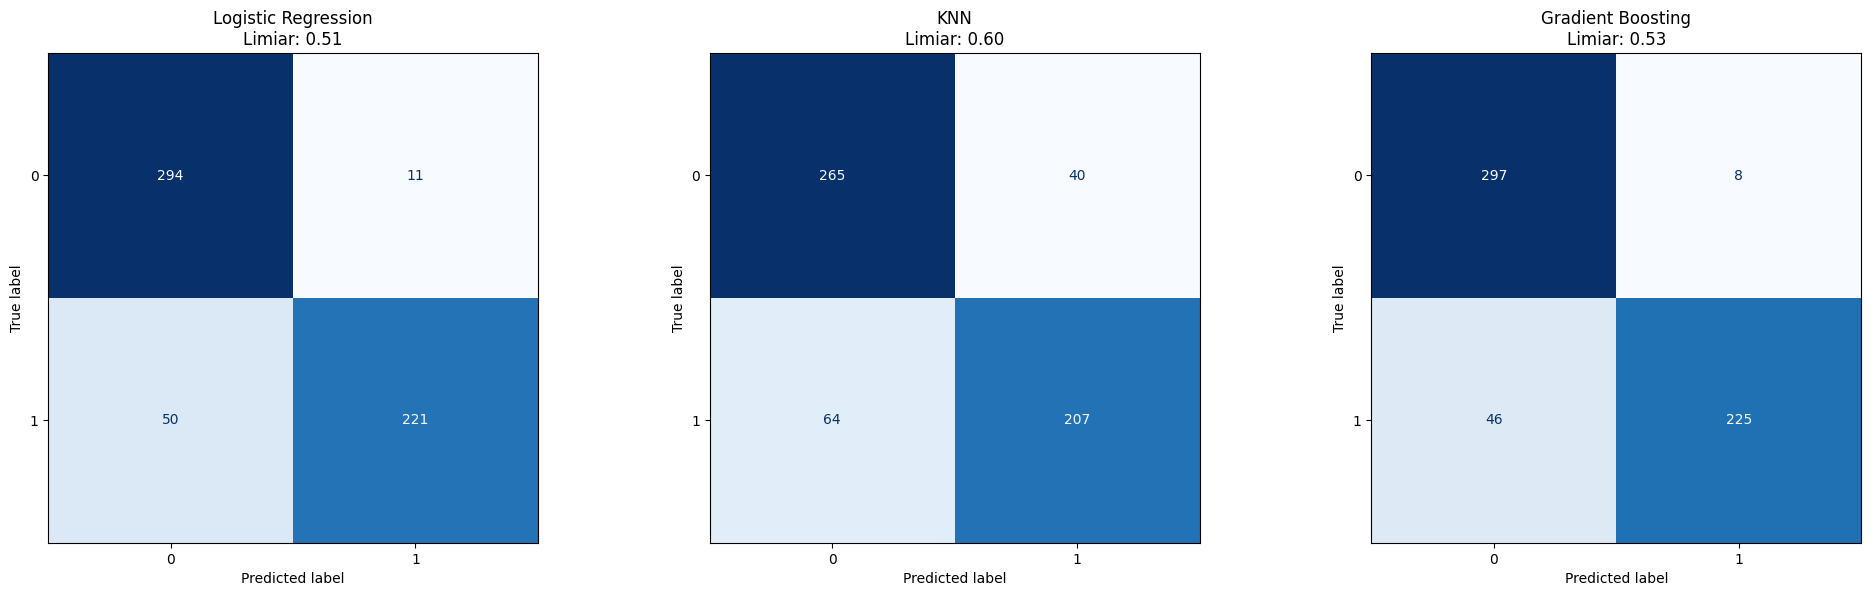

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Gradient Boosting": gbc
}

for i, (name, model) in enumerate(models.items()):
    y_probs = model.predict_proba(x_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_thresh = thresholds[np.argmax(f1_scores)]
    y_pred_tuned = (y_probs >= best_thresh)

    cm = confusion_matrix(y_test, y_pred_tuned)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nLimiar: {best_thresh:.2f}')

plt.tight_layout()
plt.show()

In [32]:
models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Gradient Boosting": gbc
}

for i, (name, model) in enumerate(models.items()):
    y_probs = model.predict_proba(x_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_thresh = thresholds[np.argmax(f1_scores)]
    y_pred_tuned = (y_probs >= best_thresh)

    print(f"\n{'='*20} {name} {'='*20}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred_tuned))


==================== Logistic Regression ====================

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.96      0.91       305
           1       0.95      0.82      0.88       271

    accuracy                           0.89       576
   macro avg       0.90      0.89      0.89       576
weighted avg       0.90      0.89      0.89       576


==================== KNN ====================

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       305
           1       0.84      0.76      0.80       271

    accuracy                           0.82       576
   macro avg       0.82      0.82      0.82       576
weighted avg       0.82      0.82      0.82       576


==================== Gradient Boosting ====================

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.97

# (2)  Predição de preços de diamantes

Import inicial do dataset

In [34]:
import pandas as pd
diamonds = pd.read_csv("https://raw.githubusercontent.com/AILAB-CEFET-RJ/cic1205/main/data/diamonds.csv")
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Separando os dados que serão usados no treino e no teste

In [35]:
from sklearn.model_selection import train_test_split

x = diamonds.drop(columns=['price'])
y = diamonds['price']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

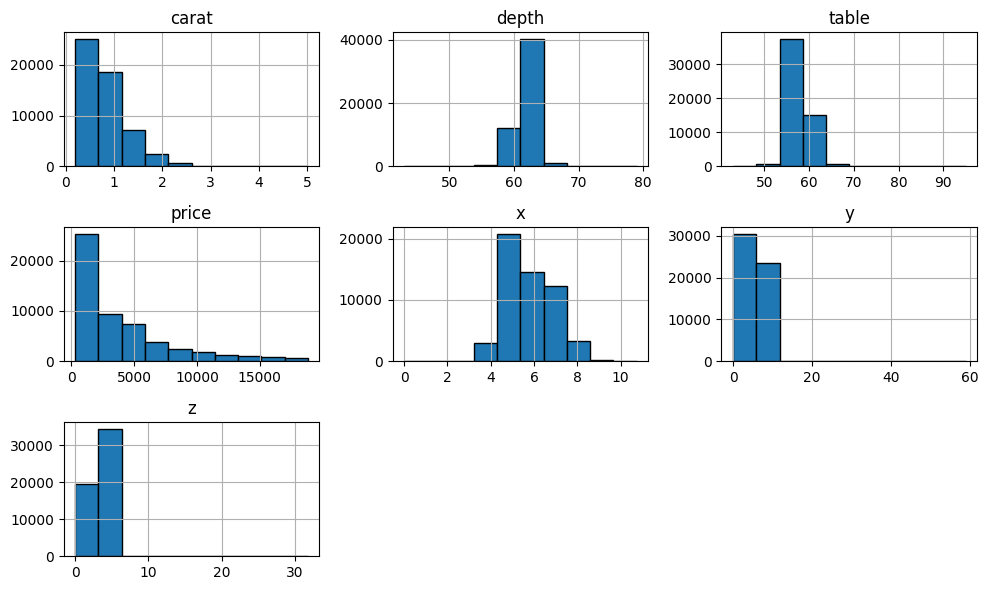

In [36]:
from matplotlib import pyplot as plt

diamonds.hist(figsize=(10, 6), edgecolor='black')
plt.tight_layout()
plt.show()

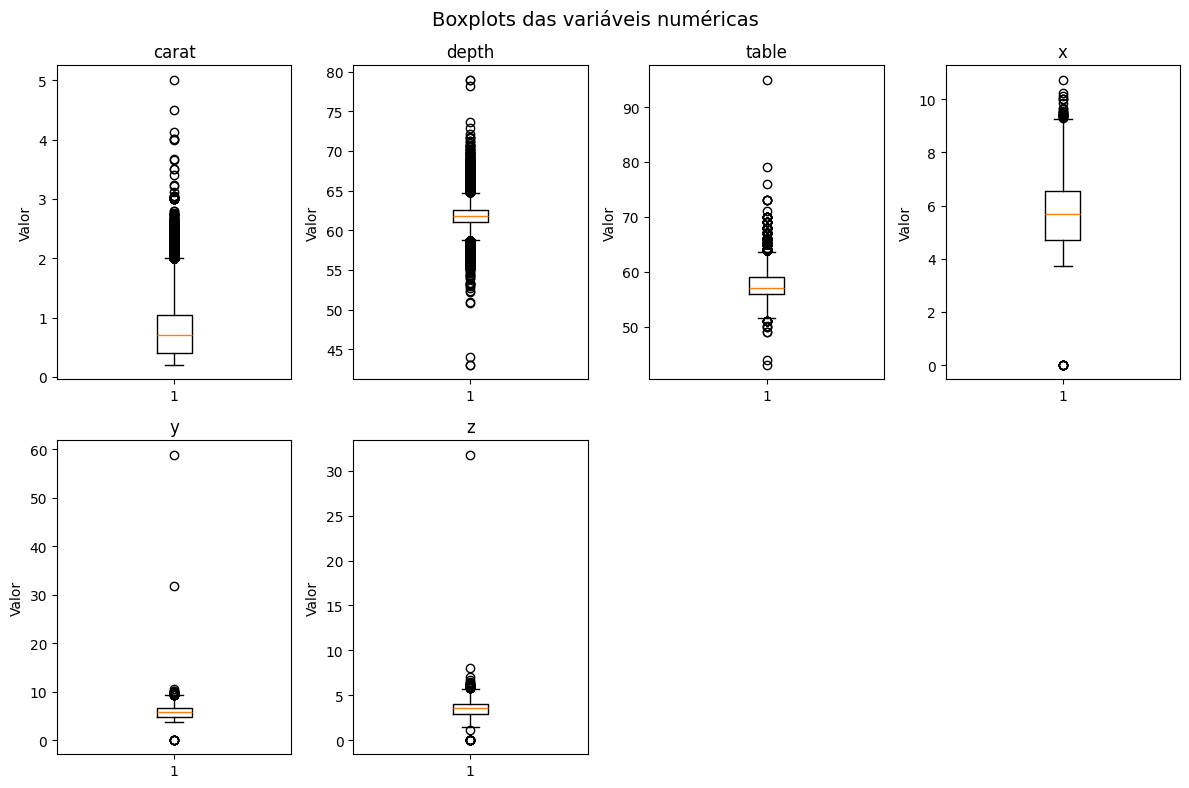

In [37]:
import matplotlib.pyplot as plt

num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols = ['cut', 'color', 'clarity']

fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(diamonds[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')

# Esconde o último subplot se houver espaço sobrando
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots das variáveis numéricas', fontsize=14)
plt.tight_layout()
plt.show()

Analizando os gráficos pode-se concluir que a maioria das variáveis se aproximam de uma distribuição normal, embora no boxplot apareçam bastantes outliers, o dataset é muito grande com mais de 50k linhas, então não fazem muita diferença. Com isso em mente usaremos normalização StandardScaler.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
import numpy as np

cut_order    = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order  = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order= ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), num_cols),
    ("ord", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), cat_cols)
])

Sobre as variáveis categóricas ajeitamos o pipeline para substituir elas usando ordinal encoder, já que há uma ordem de grandeza entre seus valores.

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    'linear': LinearRegression(),
    'knn': KNeighborsRegressor(),
    'gradboost': GradientBoostingRegressor(random_state=42)
}

pipelines = {
    name: Pipeline([('pre', preprocessor), ('model', mdl)])
    for name, mdl in models.items()
}

Inicializando os modelos

In [40]:
from sklearn.metrics import mean_squared_error, r2_score

results = {}

for name, pipe in pipelines.items():
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {'y_pred': y_pred, 'RMSE': rmse, 'R2': r2}
    print(f"{name:30s}  RMSE={rmse:,.2f}  R²={r2:.4f}")

linear                          RMSE=1,224.60  R²=0.9057
knn                             RMSE=705.21  R²=0.9687
gradboost                       RMSE=609.31  R²=0.9766


Código de treinamento usando pipeline do sklearn para processar os dados e treinar os modelos.

Os valores RMSE e R^2 indicam que os modelos conseguiram captar as relações entre as variáveis e fazem boas predições

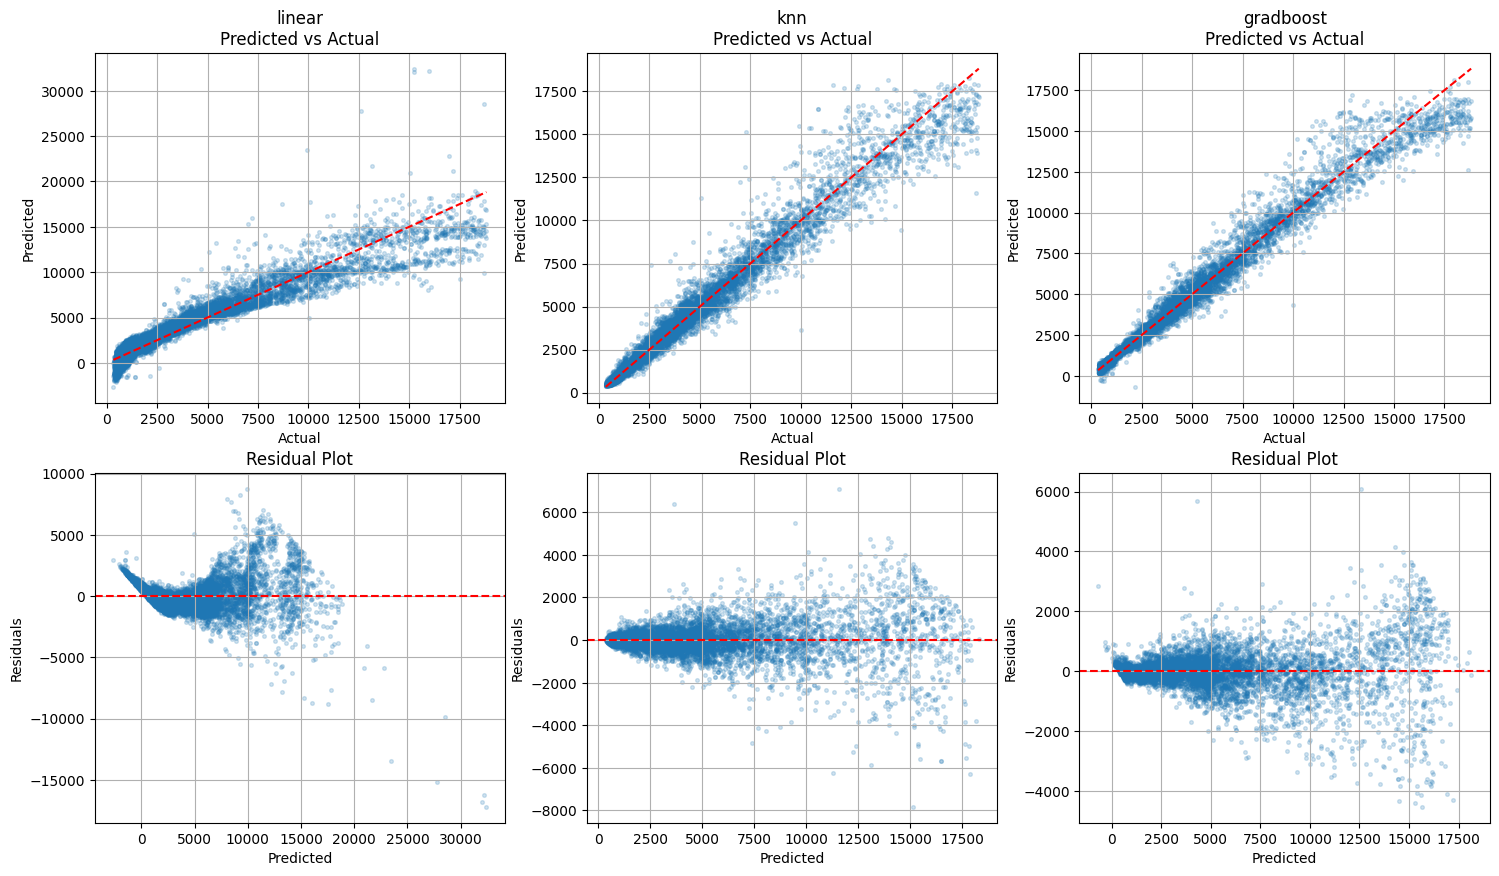

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, (name, res) in enumerate(results.items()):
  # 1. Predicted vs Actual
  y_pred = res['y_pred']
  ax = axes[0, col]
  ax.scatter(y_test, y_pred, alpha=0.2, s=7)
  ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
  ax.set_xlabel('Actual')
  ax.set_ylabel('Predicted')
  ax.set_title(f'{name}\nPredicted vs Actual')
  ax.grid(True)

# 2. Residuals Plot
  residuals = y_test - y_pred
  ax = axes[1, col]
  ax.scatter(y_pred, residuals, alpha=0.2, s=7)
  ax.axhline(0, color='red', linestyle='--')
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Residuals")
  ax.set_title("Residual Plot")
  ax.grid(True)


plt.show()

Por fim plot predição x real e residuo

o modelo linear demonstra subestimar valores nos extremos, estando consistentemente abaixo dos reais. No geral todos os modelos tem uma variância maior quanto mais alto for o preço do diamante subestimando o valor com mais frequência.

Concluindo, observa-se que os modelos se saíram bem nas predições, a maioria dos pontos está ao redor da linha o que indica uma variancia ao redor do valor correto.

# (3) Conjuntos desbalanceados - parte I

In [42]:
import pickle
import numpy as np

f = open("A652.pickle", 'rb')

(X_train, y_train, X_val, y_val, X_test, y_test) = pickle.load(f)

print(f"Shapes: ", X_train.shape, X_val.shape, X_test.shape)

Shapes:  (10012, 24) (2506, 24) (9582, 24)


In [44]:
y_train_bin = (y_train != 0).astype(int)
y_val_bin = (y_val != 0).astype(int)
y_test_bin = (y_test != 0).astype(int)

print("Distribuição no treino:")
unique, counts = np.unique(y_train_bin, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u}: {c} exemplos ({100*c/len(y_train_bin):.1f}%)")

print("\nDistribuição no validação:")
unique, counts = np.unique(y_val_bin, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u}: {c} exemplos ({100*c/len(y_val_bin):.1f}%)")

print("\nDistribuição no teste:")
unique, counts = np.unique(y_test_bin, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u}: {c} exemplos ({100*c/len(y_test_bin):.1f}%)")


Distribuição no treino:
  Classe 0: 9258 exemplos (92.5%)
  Classe 1: 754 exemplos (7.5%)

Distribuição no validação:
  Classe 0: 2277 exemplos (90.9%)
  Classe 1: 229 exemplos (9.1%)

Distribuição no teste:
  Classe 0: 8769 exemplos (91.5%)
  Classe 1: 813 exemplos (8.5%)


Transformando os dados para variáveis categóricas


*   1 --> Chuva
*   0 --> Sem Chuva

Percebe-se claramente o desbalanceamento nos dados com menos de 10% dos exemplos contendo a classe positiva

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== BASELINE (sem balanceamento) ===
              precision    recall  f1-score   support

   Sem chuva       0.94      0.99      0.97      8769
       Chuva       0.74      0.37      0.49       813

    accuracy                           0.94      9582
   macro avg       0.84      0.68      0.73      9582
weighted avg       0.93      0.94      0.93      9582



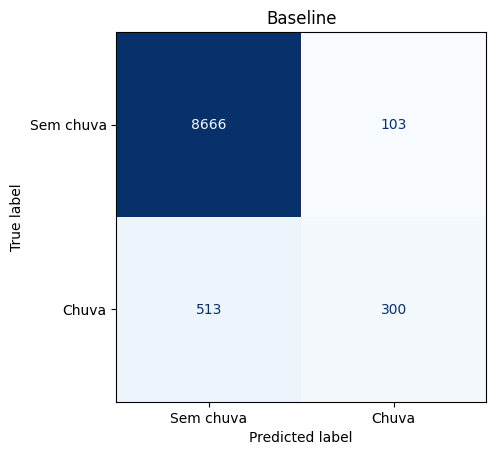

In [45]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib import pyplot as plt


gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train_bin)

y_pred_baseline = gbc.predict(X_test)

print("=== BASELINE (sem balanceamento) ===")
print(classification_report(y_test_bin, y_pred_baseline, target_names=['Sem chuva', 'Chuva']))

cm = confusion_matrix(y_test_bin, y_pred_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sem chuva', 'Chuva'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Baseline')
plt.show()

Como esperado de um modelo treinado em um dataset desbalanceado ele teve uma precisão alta da classe negativa justamente por raramente dizer q iria chuver tendo muitos falsos negativos, consequentemente o recall da classe positiva ficou bem baixo.

Treino após undersampling: (array([0, 1]), array([754, 754]))
=== UNDERSAMPLING ===
              precision    recall  f1-score   support

   Sem chuva       0.97      0.91      0.94      8769
       Chuva       0.41      0.71      0.52       813

    accuracy                           0.89      9582
   macro avg       0.69      0.81      0.73      9582
weighted avg       0.92      0.89      0.90      9582



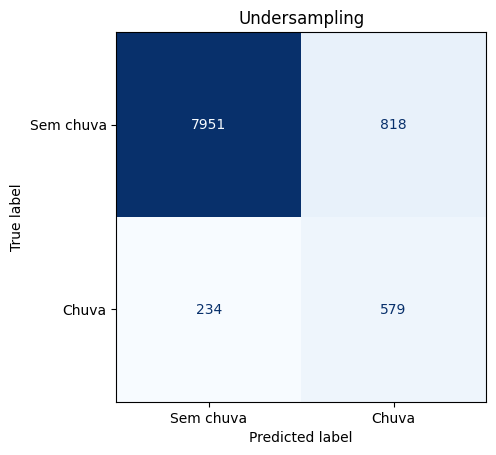

In [46]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_train_under, y_train_under = rus.fit_resample(X_train, y_train_bin)

print(f"Treino após undersampling: {np.unique(y_train_under, return_counts=True)}")

gbc_under = GradientBoostingClassifier()
gbc_under.fit(X_train_under, y_train_under)

y_pred_under = gbc_under.predict(X_test)

print("=== UNDERSAMPLING ===")
print(classification_report(y_test_bin, y_pred_under, target_names=['Sem chuva', 'Chuva']))

cm = confusion_matrix(y_test_bin, y_pred_under)
ConfusionMatrixDisplay(cm, display_labels=['Sem chuva', 'Chuva']).plot(cmap='Blues', colorbar=False)
plt.title('Undersampling')
plt.show()

Diferente do baseline esse conseguiu prever mais dias com chuva melhorando significativamente o recall, mas isso veio com o preço de perder precisão, pois agora o modelo tem maior tendencia de prever falsos positivos.

Treino após SMOTE: (array([0, 1]), array([9258, 9258]))
=== OVERSAMPLING (SMOTE) ===
              precision    recall  f1-score   support

   Sem chuva       0.97      0.94      0.95      8769
       Chuva       0.51      0.68      0.58       813

    accuracy                           0.92      9582
   macro avg       0.74      0.81      0.77      9582
weighted avg       0.93      0.92      0.92      9582



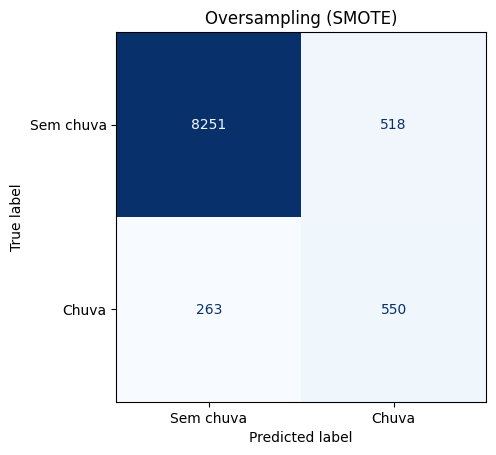

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_over, y_train_over = smote.fit_resample(X_train, y_train_bin)

print(f"Treino após SMOTE: {np.unique(y_train_over, return_counts=True)}")

gbc_over = GradientBoostingClassifier()
gbc_over.fit(X_train_over, y_train_over)

y_pred_over = gbc_over.predict(X_test)

print("=== OVERSAMPLING (SMOTE) ===")
print(classification_report(y_test_bin, y_pred_over, target_names=['Sem chuva', 'Chuva']))

cm = confusion_matrix(y_test_bin, y_pred_over)
ConfusionMatrixDisplay(cm, display_labels=['Sem chuva', 'Chuva']).plot(cmap='Blues', colorbar=False)
plt.title('Oversampling (SMOTE)')
plt.show()

Parecido com o undersampling o método de oversampling também conseguiu prever mais dias com chuva melhorando significativamente o recall comparando ao baseline, mas com o custo de perder precisão,pela maior tendencia de levantar falsos positivos.

Melhor limiar (max F1 na validação): 0.20
=== ALTERAÇÃO DE LIMIAR ===
              precision    recall  f1-score   support

   Sem chuva       0.96      0.97      0.96      8769
       Chuva       0.62      0.59      0.60       813

    accuracy                           0.93      9582
   macro avg       0.79      0.78      0.78      9582
weighted avg       0.93      0.93      0.93      9582



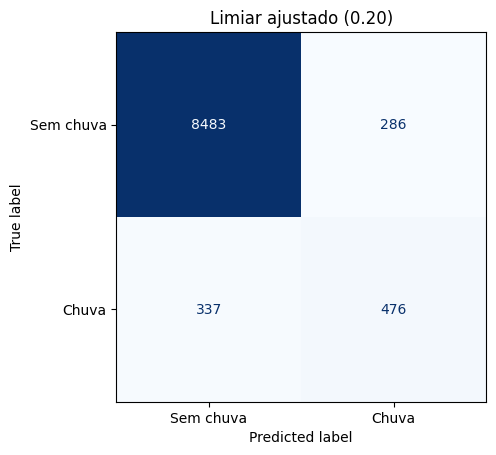

In [49]:
from sklearn.metrics import f1_score

y_val_proba = gbc.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val_bin, (y_val_proba >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Melhor limiar (max F1 na validação): {best_threshold:.2f}")

y_test_proba = gbc.predict_proba(X_test)[:, 1]
y_pred_limiar = (y_test_proba >= best_threshold).astype(int)

print("=== ALTERAÇÃO DE LIMIAR ===")
print(classification_report(y_test_bin, y_pred_limiar, target_names=['Sem chuva', 'Chuva']))

cm = confusion_matrix(y_test_bin, y_pred_limiar)
ConfusionMatrixDisplay(cm, display_labels=['Sem chuva', 'Chuva']).plot(cmap='Blues', colorbar=False)
plt.title(f'Limiar ajustado ({best_threshold:.2f})')
plt.show()

Por fim ajustar o limiar não melhorou tanto o recall quando comparado ao oversampling e undersampling, mas houve um balanço maior número de falsos positivos e falsos negativos, parecendo um meio termo entre as outras estratégias e o modelo base

Conclusão final: Embora tenham tido suas diferenças as todas as técnicas empregadas demosntraram melhorar a previsão da classe minoritária em relação ao modelo base, que é a classe mais importante. Isso mostra a importancia de tratar corretamente conjuntos desbalanceados para melhorar o desempenho do modelo.

# (4) Conjuntos desbalanceados - parte II

Primeiro é treinado o modelo classificador e selecionado o limiar que maximiza f1

In [50]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
import numpy as np

# Versões binárias já criadas na questão anterior
# y_train_bin, y_val_bin, y_test_bin

C = GradientBoostingClassifier()
C.fit(X_train, y_train_bin)

y_val_proba = C.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val_bin, (y_val_proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
print(f"Melhor limiar: {best_t:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Melhor limiar: 0.19


Então usamos o classificador para separar os dias que chuveram do restante

In [51]:
y_train_proba = C.predict_proba(X_train)[:, 1]
y_train_C = (y_train_proba >= best_t).astype(int)

mask_train_1 = y_train_C == 1
X_train_1 = X_train[mask_train_1]
y_train_1 = y_train[mask_train_1]

print(f"Exemplos usados para treinar: {X_train_1.shape[0]} de {X_train.shape[0]}")

Exemplos usados para treinar: 849 de 10012


Assim, podemos treinar o modelo de regressão em cima dos dados separados.
Também é treinado um modelo sobre todo o conjunto de treinamento para servir de comparação.

In [52]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

R = GradientBoostingRegressor()
R.fit(X_train_1, y_train_1)

y_test_proba = C.predict_proba(X_test)[:, 1]
y_test_C = (y_test_proba >= best_t).astype(int)

y_pred_combinado = np.zeros(len(X_test))
mask_test_1 = y_test_C == 1
y_pred_combinado[mask_test_1] = R.predict(X_test[mask_test_1])


# ========== Modelo base ==========

R_baseline = GradientBoostingRegressor()
R_baseline.fit(X_train, y_train)
y_pred_baseline = R_baseline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Separado os dados por faixa de chuva de acordo com os valores da tabela

In [53]:
y_test = y_test.flatten()

faixas = [
    ("Sem chuva / Leve",  (y_test >= 0)  & (y_test < 5)),
    ("Moderada", (y_test >= 5)  & (y_test < 25)),
    ("Forte", (y_test >= 25) & (y_test < 50)),
    ("Tempestade", (y_test >= 50))
]

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


print("RMSE por faixa de severidade:\n")
for nome, mask in faixas:
    r_comb = rmse(y_test[mask], y_pred_combinado[mask])
    r_base = rmse(y_test[mask], y_pred_baseline[mask])
    print(f"  - {nome} ({mask.sum()} exemplos): combinado={r_comb:.4f} | baseline={r_base:.4f}\n")

print(f"RMSE total - modelo combinado:    {rmse(y_test, y_pred_combinado):.4f}")
print(f"RMSE total - baseline:            {rmse(y_test, y_pred_baseline):.4f}")

# Sem ajuste de limiar
y_test_C_default = C.predict(X_test)
y_pred_sem_limiar = np.zeros(len(X_test))
mask_default = y_test_C_default == 1
y_pred_sem_limiar[mask_default] = R.predict(X_test[mask_default])

print(f"RMSE total - sem ajuste de limiar: {rmse(y_test, y_pred_sem_limiar):.4f}")

RMSE por faixa de severidade:

  - Sem chuva / Leve (9525 exemplos): combinado=0.5714 | baseline=0.4858

  - Moderada (51 exemplos): combinado=9.6516 | baseline=9.6908

  - Forte (4 exemplos): combinado=24.2577 | baseline=25.7456

  - Tempestade (2 exemplos): combinado=59.7241 | baseline=60.8631


RMSE total - modelo combinado:    1.3456
RMSE total - baseline:            1.3358
RMSE total - sem ajuste de limiar: 1.3294


Com base no experimento o modelo que usa classificador não produziu um melhor resultado, mesmo sem ajuste o modelo simples treinado sem o classificador foi um pouco melhor em chuvas fracas e próximo o suficiente em chuvas fortes para a diferença entre os modelos não ser significativa. Isso sem o overhead computacional de ter mais de um modelo para predição.

Separar o valor da chuva por faixas é mais correto do que só revelar o rmse geral por ser muito mais importante conseguir prever tempestades e chuvas fortes do que chuvas fracas. Assim pode-se escolher o melhor modelo com mais precisão nesses casos. Mas independentemente o modelo sem classificador foi o melhor, pelo valor próximo sem o custo computacional a mais.

# (5) Calibração de modelos

Primeiro será necessário retreinar os modelos pois algumas variáveis foram reescritas. Além disso, uma parte do conjunto de treino será removida e usada para calibrar o modelo, assim não ocorrerá data leakage e usaremos o conjunto de teste para avaliação final

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

x_train = df_scaled.drop('CLASSE', axis=1)
y_train = df_scaled['CLASSE']
x_test  = df_test.drop('CLASSE', axis=1)
y_test  = df_test['CLASSE']

x_train_base, x_cal, y_train_base, y_cal = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

lr  = LogisticRegression()
knn = KNeighborsClassifier()
gbc = GradientBoostingClassifier()

lr.fit(x_train_base, y_train_base)
knn.fit(x_train_base, y_train_base)
gbc.fit(x_train_base, y_train_base)

print('modelos treinados')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


modelos treinados


Dessa forma podemos comelçar investigando a situação dos modelos treinados anteriormente olhando a curva de calibração

  Logistic Regression: 0.1014
  KNN: 0.1458
  Gradient Boosting: 0.0849


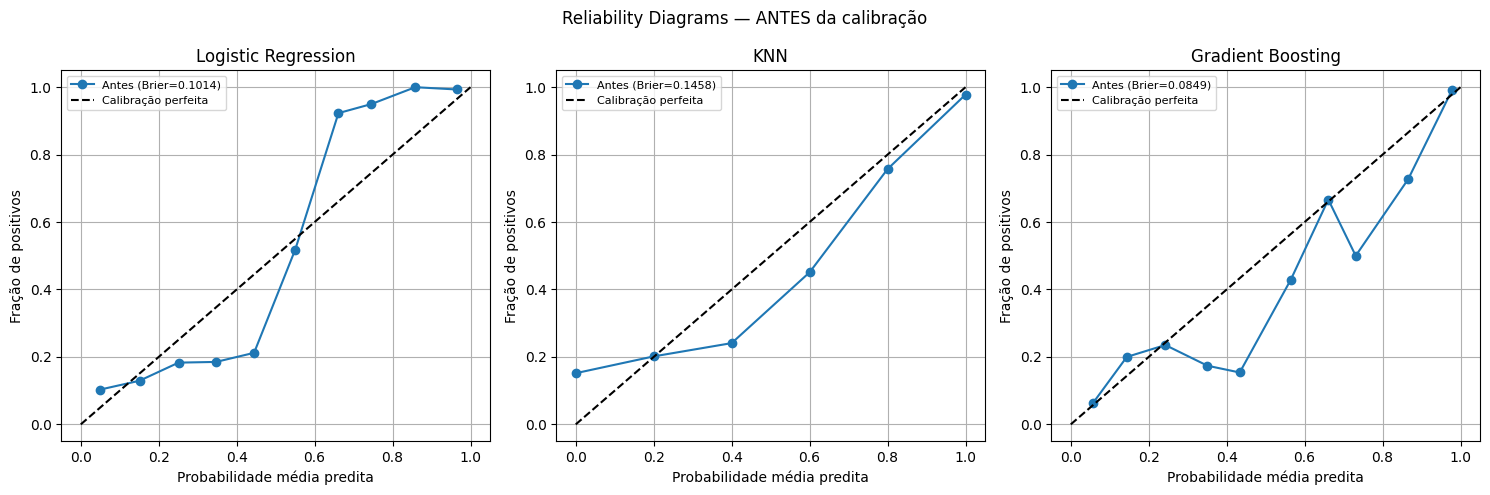

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Gradient Boosting": gbc
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_probs = model.predict_proba(x_test)[:, 1]
    brier = brier_score_loss(y_test, y_probs)
    print(f"  {name}: {brier:.4f}")

    frac_pos, mean_pred = calibration_curve(y_test, y_probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', label=f'Antes (Brier={brier:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', label='Calibração perfeita')
    ax.set_title(name)
    ax.set_xlabel('Probabilidade média predita')
    ax.set_ylabel('Fração de positivos')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle('Reliability Diagrams — ANTES da calibração')
plt.tight_layout()
plt.show()

Interpretando as curvas pode-se ver que a regressão logística foi confiante demais em valores baixos enquanto em valores altos foi pessimista.
O modelo KNN inciaomente está acima da linha indicando pouca confiança, mas no restante da curva demonstra ser confiante demais.
Por fim o modelo Grandient Boosting demonstra ser no geral confiante de mais por estar abaixo da linha.

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.1


Brier Scores DEPOIS da calibração:
  Logistic Regression: original=0.1014 | sigmoid=0.0983 | isotonic=0.0964
  KNN: original=0.1458 | sigmoid=0.1413 | isotonic=0.1387
  Gradient Boosting: original=0.0849 | sigmoid=0.0836 | isotonic=0.0867


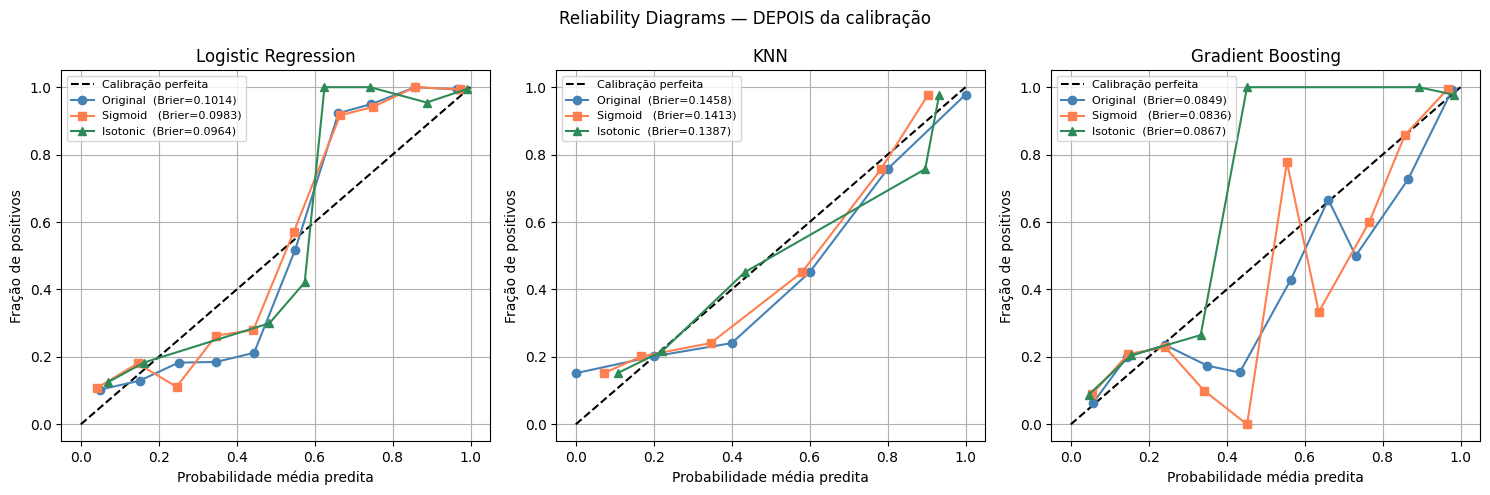

In [63]:
cal_models = {}
for name, model in models.items():
    sig = CalibratedClassifierCV(model, cv='prefit', method='sigmoid')
    iso = CalibratedClassifierCV(model, cv='prefit', method='isotonic')
    sig.fit(x_cal, y_cal)
    iso.fit(x_cal, y_cal)
    cal_models[name] = {'original': model, 'sigmoid': sig, 'isotonic': iso}

print("\nBrier Scores DEPOIS da calibração:")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_probs_orig = model.predict_proba(x_test)[:, 1]
    brier_orig   = brier_score_loss(y_test, y_probs_orig)

    y_probs_sig  = cal_models[name]['sigmoid'].predict_proba(x_test)[:, 1]
    brier_sig    = brier_score_loss(y_test, y_probs_sig)

    y_probs_iso  = cal_models[name]['isotonic'].predict_proba(x_test)[:, 1]
    brier_iso    = brier_score_loss(y_test, y_probs_iso)

    print(f"  {name}: original={brier_orig:.4f} | sigmoid={brier_sig:.4f} | isotonic={brier_iso:.4f}")

    frac_orig, mean_orig = calibration_curve(y_test, y_probs_orig, n_bins=10)
    frac_sig,  mean_sig  = calibration_curve(y_test, y_probs_sig,  n_bins=10)
    frac_iso,  mean_iso  = calibration_curve(y_test, y_probs_iso,  n_bins=10)

    ax.plot([0, 1], [0, 1], 'k--', label='Calibração perfeita')
    ax.plot(mean_orig, frac_orig, marker='o', label=f'Original  (Brier={brier_orig:.4f})', color='steelblue')
    ax.plot(mean_sig,  frac_sig,  marker='s', label=f'Sigmoid   (Brier={brier_sig:.4f})',  color='coral')
    ax.plot(mean_iso,  frac_iso,  marker='^', label=f'Isotonic  (Brier={brier_iso:.4f})',  color='seagreen')

    ax.set_title(name)
    ax.set_xlabel('Probabilidade média predita')
    ax.set_ylabel('Fração de positivos')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle('Reliability Diagrams — DEPOIS da calibração')
plt.tight_layout()
plt.show()

Me parece que o modelo que mais se beneficiou da calibragem foi o KNN, que melhorou tanto na sigmoid quanto na isotonica, com essa ultima conseguindo acompanhar bem a linha central.
O modelo logistic regression se benficiou um pouco, o método sigmoid pareceu melhor por ter uma variância menor ao redor da linha central.
Gradient boosting não parece ter se beneficiado da calibragem, a calibragem isotonica acabou tendo um brier maior e a sigmoid parece ter uma variância maior.

# (6) Validação cruzada aninhada

Importando o dataset e realizando os mesmo tratamentos da questão 2

In [65]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import numpy as np

diamonds = pd.read_csv("https://raw.githubusercontent.com/AILAB-CEFET-RJ/cic1205/main/data/diamonds.csv")

x = diamonds.drop(columns=['price'])
y = diamonds['price']

num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols = ['cut', 'color', 'clarity']

cut_order    = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order  = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order= ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), num_cols),
    ("ord", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), cat_cols)
])

Definição dos hyperparâmetros e faixas que serão analizados

In [66]:
from scipy.stats import randint, uniform

param_dist_knn = {
    'model__n_neighbors': np.arange(3, 31),
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

param_dist_gbr = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 7),
    'model__learning_rate': uniform(0.01, 0.19), # contínuo de 0.01 a 0.20
    'model__subsample': uniform(0.7, 0.3), # contínuo de 0.70 a 1.0
    'model__min_samples_leaf': randint(1, 20)
}

Seleção do melhor modelo com cross validation

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV
import numpy as np

outer_cv = KFold(n_splits=3, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

resultados = {}

for name, model_class, param_dist in [
    ("KNN", KNeighborsRegressor(), param_dist_knn),
    ("GradientBoosting", GradientBoostingRegressor(random_state=42), param_dist_gbr)
]:
    print(f"Processando {name}...")

    pipe = Pipeline([
        ('pre',   preprocessor),
        ('model', model_class)
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=10,
        cv=inner_cv,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )

    outer_scores = cross_val_score(
        search,
        x, y,
        cv=outer_cv,
        scoring='r2',
        n_jobs=-1
    )

    resultados[name] = outer_scores
    print(f"  R2 por fold: {np.round(outer_scores, 5)}")
    print(f"  R2 médio:    {outer_scores.mean():.5f} ± {outer_scores.std():.5f}\n")

Processando KNN...
  R2 por fold: [0.97502 0.97326 0.97554]
  R2 médio:    0.97461 ± 0.00097

Processando GradientBoosting...
  R2 por fold: [0.9825  0.98063 0.98267]
  R2 médio:    0.98193 ± 0.00092



Como GradientBoosting obteve as melhores métricas no conjunto de dados, usaremos ele para procurar a melhor configuração de hiperparâmetros usando a estratégia random search.

In [13]:
melhores_params = {}

name = "GradientBoosting"

pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
  ])

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist_gbr,
    n_iter=10,
    cv=inner_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1
  )

search.fit(x, y)
melhores_params[name] = search.best_params_

print(f"\nMelhores hiperparâmetros — {name}:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")
print(f"  R^2 (validação interna): {search.best_score_:.6f}")


Melhores hiperparâmetros — GradientBoosting:
  model__learning_rate: 0.020718200015149048
  model__max_depth: 6
  model__min_samples_leaf: 12
  model__n_estimators: 393
  model__subsample: 0.7002336297523043
  R^2 (validação interna): 0.981935
